# EU AI Ethics Assistant — Expert Agent with Groq, RAG and LangGraph


An expert conversational agent on **European AI ethics and regulation**, grounded in 4 official/academic sources:
1. EU AI Act (full legal text)
2. A Survey on Bias and Fairness in Machine Learning (Mehrabi et al.)
3. European Parliament study: The Ethics of AI — Issues and Initiatives
4. EU Ethics Guidelines for Trustworthy AI (AI HLEG)

**Pipeline:** PDF ingestion → chunking → local Sentence Transformers embeddings → ChromaDB → LangGraph agent (retrieve → generate) with conversation memory, answered by Groq.

> **⚠️ Note on LLM/embeddings:** this project originally used Google Gemini for both the LLM and embeddings, as specified in the assignment brief. Gemini's free-tier quota (1,000 embedding requests/day, 100 requests/minute) repeatedly blocked development — the exact failure this notebook hit before the migration — so the stack was deliberately switched to **Groq** (LLM) + **local Sentence Transformers** (embeddings), both genuinely free with no rate limits. The RAG architecture, LangGraph agent design, conversation memory, and system prompt are all unchanged from the original design. Full rationale in `DECISIONS.md`.

**By Nazmul Farooquee**

**uuid - 98e732f8-7758-4b2a-aa88-39323ebd9bef**

In [1]:
# --- Imports & environment ---
import os
import sys

# Fail loudly if the wrong kernel is selected — this project's venv lives in
# ai_ethics/, and mixing it up with an unrelated project's kernel is the most
# common source of confusing ModuleNotFoundError's during setup.
print("Python executable:", sys.executable)
if "ai_ethics" not in sys.executable:
    raise RuntimeError(
        "Wrong kernel selected!\n"
        f"Current interpreter: {sys.executable}\n"
        "This notebook needs the project's own venv kernel "
        "('!!! USE THIS ONE - AI ETHICS ASSISTANT !!!').\n"
        "Fix: click the kernel name (top-right) -> Select Another Kernel -> Python Environments -> "
        "pick the interpreter under ai-ethics-assistant\\ai_ethics\\Scripts\\python.exe, "
        "then Ctrl+Shift+P -> 'Jupyter: Restart Kernel', then re-run this cell."
    )

from dotenv import load_dotenv

# Load GROQ_API_KEY from the .env file in the project root
load_dotenv("../.env")

# Fail fast if the key is missing (better than a cryptic error later)
assert os.getenv("GROQ_API_KEY"), "GROQ_API_KEY not found — check your .env file"

# --- Central configuration (one place to tune everything) ---
DATA_DIR        = "../data"
CHROMA_DIR      = "../chroma_db"
COLLECTION_NAME = "ai_ethics_eu"

LLM_MODEL       = "llama-3.1-8b-instant"  # free, fast, no rate limits (Groq)
EMBEDDING_MODEL = "all-MiniLM-L6-v2"      # local Sentence Transformers — no API, no quota

CHUNK_SIZE      = 1400   # characters per chunk
CHUNK_OVERLAP   = 150    # overlap so ideas aren't cut mid-sentence
TOP_K           = 4      # chunks retrieved per question

print("Configuration loaded ✔")

Python executable: C:\Users\nazmu\OneDrive\Desktop\ai-ethics-assistant\ai_ethics\Scripts\python.exe
Configuration loaded ✔


WHY (for DECISIONS.md): chunk_size 1400 with 150 overlap is sized for two reasons: (1) dense legal/academic text needs big enough chunks to preserve a full legal provision, and (2) it keeps chunk count reasonable for fast local embedding. Since embeddings run locally via Sentence Transformers, there's no daily API quota to worry about (unlike the Gemini embeddings this project started with). TOP_K=4 balances context richness vs. noise. All tunable from one cell.

In [2]:
from langchain_community.document_loaders import PyPDFLoader
import re

def clean_text(text: str) -> str:
    """Light cleaning for PDF-extracted text."""
    text = re.sub(r"\s+", " ", text)          # collapse whitespace/newlines
    text = re.sub(r"-\s+", "", text)          # fix hyphenated line breaks ("regu- lation")
    return text.strip()

# Map each file to a human-readable source name (used later in citations)
SOURCES = {
    "EU-AI-Act.pdf":                 "EU AI Act",
    "bias_fairness_survey.pdf":      "Bias & Fairness Survey (Mehrabi et al.)",
    "ethics_of_ai_study.pdf":        "EP Study: Ethics of AI",
    "trustworthy_ai_guidelines.pdf": "Ethics Guidelines for Trustworthy AI",
}

documents = []
for filename, source_name in SOURCES.items():
    path = os.path.join(DATA_DIR, filename)
    loader = PyPDFLoader(path)
    pages = loader.load()                     # one Document per page
    for page in pages:
        page.page_content = clean_text(page.page_content)
        page.metadata["source_name"] = source_name   # attach clean source label
    documents.extend(pages)
    print(f"Loaded {len(pages):>3} pages ← {source_name}")

print(f"\nTotal pages loaded: {len(documents)}")

Loaded  50 pages ← EU AI Act


Loaded  34 pages ← Bias & Fairness Survey (Mehrabi et al.)


Loaded 128 pages ← EP Study: Ethics of AI


Loaded  41 pages ← Ethics Guidelines for Trustworthy AI

Total pages loaded: 253


WHY: metadata source_name lets the agent say which document an answer came from — a big credibility boost in the demo.

In [3]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    separators=["\n\n", "\n", ". ", " ", ""],  # split at natural boundaries first
)

chunks = splitter.split_documents(documents)
print(f"Created {len(chunks)} chunks from {len(documents)} pages")

# Sanity check — inspect one chunk
print("\n--- Sample chunk ---")
print("Source:", chunks[50].metadata["source_name"])
print(chunks[50].page_content[:400])

Created 758 chunks from 253 pages

--- Sample chunk ---
Source: EU AI Act
19 P e ople at the Centre S ol idarity and Inclusion F r e edom of Choice P a r ticipation S a fety and Security S us tainability Article 13: Transparency and Provision of Information to Deployers: High -risk AI systems must be designed to ensure sufficient transparency, enabling deployers to interpret and use the system's output appropriately. This includes providing clear instructions for use, w


WHY: RecursiveCharacterTextSplitter tries paragraph → sentence → word boundaries in order, so chunks stay semantically coherent. Overlap ensures a definition that starts at a chunk edge isn't lost.

In [4]:
from langchain_chroma import Chroma
from sentence_transformers import SentenceTransformer


class LocalEmbeddings:
    """Local sentence-transformers embeddings wrapper for LangChain compatibility."""

    def __init__(self, model_name: str):
        print(f"Loading embedding model: {model_name}")
        self.model = SentenceTransformer(model_name)

    def embed_documents(self, texts: list[str]) -> list[list[float]]:
        return self.model.encode(texts, show_progress_bar=True).tolist()

    def embed_query(self, text: str) -> list[float]:
        return self.model.encode(text, show_progress_bar=False).tolist()


embeddings = LocalEmbeddings(EMBEDDING_MODEL)

vectorstore = Chroma(
    collection_name=COLLECTION_NAME,
    embedding_function=embeddings,
    persist_directory=CHROMA_DIR,
)

# Idempotent: re-running this cell (e.g. during a live "Run All" demo) must
# not re-add the same chunks on top of an already-populated store — Chroma
# assigns each add_documents() call fresh random ids, so a second call
# silently duplicates every chunk instead of erroring.
existing = vectorstore._collection.count()
if existing >= len(chunks):
    print(f"Store already has {existing} chunks — skipping re-indexing.")
else:
    print(f"Indexing {len(chunks)} chunks...")
    vectorstore.add_documents(chunks)

print(f"\nIndexed {vectorstore._collection.count()} chunks in ChromaDB ✔")

Loading embedding model: all-MiniLM-L6-v2


Store already has 758 chunks — skipping re-indexing.

Indexed 758 chunks in ChromaDB ✔


NOTE: Local embedding runs in one shot — no batching or rate-limit backoff needed (that machinery was only required for the Gemini free-tier quota this project used before switching to local Sentence Transformers). Indexing ~250 pages (~750 chunks) takes about 13 seconds, and the cell above is idempotent — re-running it (including during a live "Run All" demo) reuses the existing store instead of duplicating chunks.

In [5]:
# --- Reload existing store (use this after the first run) ---
vectorstore = Chroma(
    collection_name=COLLECTION_NAME,
    embedding_function=embeddings,
    persist_directory=CHROMA_DIR,
)
print(f"Loaded existing collection: {vectorstore._collection.count()} chunks")

Loaded existing collection: 758 chunks


TIP (rubric best practice): test first with ONE pdf / a few pages to validate the pipeline, then index everything.

In [6]:
retriever = vectorstore.as_retriever(search_kwargs={"k": TOP_K})

test_queries = [
    "What are high-risk AI systems under the EU AI Act?",
    "What types of bias exist in machine learning?",
    "What are the seven requirements for trustworthy AI?",
]

for q in test_queries:
    print(f"\n{'='*70}\nQUERY: {q}\n{'='*70}")
    results = retriever.invoke(q)
    for i, doc in enumerate(results, 1):
        print(f"\n[{i}] Source: {doc.metadata['source_name']} (page {doc.metadata.get('page', '?')})")
        print(doc.page_content[:250], "...")


QUERY: What are high-risk AI systems under the EU AI Act?

[1] Source: EU AI Act (page 8)
8 P e ople at the Centre S ol idarity and Inclusion F r e edom of Choice P a r ticipation S a fety and Security S us tainability ‘Innovation encouraged via mitigation mechanisms’, AMLEGALS The EU AI Act's multi-faceted approach hopes to build a respo ...

[2] Source: EU AI Act (page 5)
5 P e ople at the Centre S ol idarity and Inclusion F r e edom of Choice P a r ticipation S a fety and Security S us tainability 1. Executive Summary The EU AI Act represents a comprehensive and pioneering regulatory framework that aims to establish  ...

[3] Source: EU AI Act (page 19)
. This includes providing clear instructions for use, which helps users understand the system's capabilities and limitations, thereby supporting informed decision-making. Article 86: Right to Explanation of Individual Decision-Making: This article pr ...

[4] Source: EU AI Act (page 37)
36 P e ople at the Centre S ol idarity and Inc

WHAT TO CHECK: each query should return chunks from the right document (AI Act question → AI Act chunks, bias question → survey chunks). If not, revisit chunk size. Write a short markdown cell after this documenting what you observed — that's "Excellent" tier documentation.

In [7]:
SYSTEM_PROMPT = """You are an expert assistant on European AI ethics and regulation.

Your knowledge base consists of four authoritative sources:
1. The EU AI Act (official legal text)
2. "A Survey on Bias and Fairness in Machine Learning" (Mehrabi et al.)
3. The European Parliament study "The Ethics of Artificial Intelligence: Issues and Initiatives"
4. The EU "Ethics Guidelines for Trustworthy AI" (AI HLEG)

RULES:
1. Answer ONLY using the context provided below. Never invent facts, article numbers, or legal requirements.
2. If the context does not contain the answer, say clearly: "I don't have enough information in my knowledge base to answer that" — and suggest what the user could ask instead.
3. Mention which source your answer is based on (e.g., "According to the EU AI Act...").
4. Be clear and educational: your users may be developers, students, or policymakers with no legal background. Explain technical or legal terms briefly when you use them.
5. Be concise: 2–4 short paragraphs maximum, unless the user asks for more detail.
6. You are not a lawyer. For legal decisions, recommend consulting a qualified professional.

CONTEXT FROM KNOWLEDGE BASE:
{context}
"""

### System Prompt — Design Justification

- **Grounding rule (1–2):** forces RAG-only answers and an explicit "I don't know" path — prevents hallucinated article numbers, the most dangerous failure for a legal/ethics domain.
- **Source attribution (3):** users can verify claims; builds trust and demonstrates retrieval is working.
- **Audience adaptation (4):** the tool targets non-experts — the whole point is making ~250 pages of regulation accessible.
- **Brevity (5):** a chatbot that answers with walls of text defeats its purpose.
- **Legal disclaimer (6):** responsible-AI practice for a compliance-adjacent domain — fitting for a project *about* AI ethics.

### Supervisor / Verification Agent — Why It's Needed Here

A single-pass RAG agent can still hallucinate: the LLM sometimes fabricates a plausible-sounding citation (e.g. "EU AI Act, Article 6") even when the retrieved context doesn't contain it, especially on multi-turn follow-ups where the question is vague. For a compliance and ethics assistant, an unverified fabricated legal claim is the worst possible failure mode — worse than saying "I don't know."

So the agent adds a second LLM as a **supervisor**: after `generate` drafts an answer, a `verify` node re-checks that draft against the same retrieved context and returns `VALID` or `INVALID: <reason>`. If `INVALID`, a `revise` node regenerates the answer once, explicitly told what was unsupported. Only the final, checked answer is added to the conversation. This is a real agent-to-agent pattern (generator + critic) rather than a single model policing itself in one pass, and it's cheap — one extra Groq call in the common case, two in the rare correction case.

In [8]:
from typing import Annotated, Literal, TypedDict
from langchain_core.messages import AIMessage, SystemMessage, HumanMessage, BaseMessage
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver

VERIFY_PROMPT = """You are a strict compliance reviewer for an AI ethics assistant. Your only \
job is to check whether a DRAFT ANSWER is fully grounded in the given CONTEXT — no invented \
facts, article numbers, or legal claims that aren't directly supported.

CONTEXT:
{context}

DRAFT ANSWER:
{draft}

Reply with exactly "VALID" if every claim in the draft is directly supported by the context \
(or the draft correctly states it doesn't have enough information). Otherwise reply with \
"INVALID: " followed by a one-sentence explanation of the unsupported claim.
"""

REVISE_PROMPT = """Your previous draft failed a groundedness check: {reason}

Rewrite the answer to the question below using ONLY the context provided, correcting this \
issue. If the context doesn't actually support an answer, say so explicitly.

QUESTION: {question}
"""

# --- 1. Agent state ---
# `add_messages` automatically APPENDS new messages instead of overwriting —
# this is what gives the agent conversation memory across turns. `draft` and
# `verification` are scratch fields used between generate/verify/revise and
# are never themselves added to conversation history.
class AgentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    context: str          # retrieved chunks for the CURRENT question
    draft: str            # candidate answer, pending verification
    verification: str     # "VALID" or "INVALID: <reason>"

# --- 2. LLM ---
llm = ChatGroq(model=LLM_MODEL, temperature=0.2)
# temperature 0.2 → factual, low-creativity answers (right for legal/ethics content)

# --- 3. Node: retrieve ---
def retrieve(state: AgentState) -> dict:
    """Take the latest user question, fetch top-k chunks from ChromaDB."""
    question = state["messages"][-1].content
    docs = retriever.invoke(question)
    context = "\n\n---\n\n".join(
        f"[Source: {d.metadata['source_name']}]\n{d.page_content}" for d in docs
    )
    return {"context": context}

# --- 4. Node: generate ---
def generate(state: AgentState) -> dict:
    """Build the prompt (system + context + full history) and draft an answer with Groq."""
    system = SystemMessage(content=SYSTEM_PROMPT.format(context=state["context"]))
    response = llm.invoke([system] + state["messages"])
    return {"draft": response.content}

# --- 5. Node: verify (the supervisor) ---
def verify(state: AgentState) -> dict:
    """Second LLM call: check the draft is fully grounded in the retrieved context."""
    check = VERIFY_PROMPT.format(context=state["context"], draft=state["draft"])
    result = llm.invoke([HumanMessage(content=check)])
    return {"verification": result.content.strip()}

def route_after_verify(state: AgentState) -> Literal["finalize", "revise"]:
    return "finalize" if state["verification"].upper().startswith("VALID") else "revise"

# --- 6. Node: revise ---
def revise(state: AgentState) -> dict:
    """Regenerate the answer once, addressing the specific verification failure."""
    question = state["messages"][-1].content
    system = SystemMessage(content=SYSTEM_PROMPT.format(context=state["context"]))
    correction = HumanMessage(
        content=REVISE_PROMPT.format(reason=state["verification"], question=question)
    )
    response = llm.invoke([system] + state["messages"] + [correction])
    return {"draft": response.content}

# --- 7. Node: finalize ---
def finalize(state: AgentState) -> dict:
    """Commit the (possibly revised) draft as the agent's final answer."""
    return {"messages": [AIMessage(content=state["draft"])]}   # add_messages appends this to history

# --- 8. Build the graph: retrieve -> generate -> verify -> [finalize | revise -> finalize] ---
graph_builder = StateGraph(AgentState)
graph_builder.add_node("retrieve", retrieve)
graph_builder.add_node("generate", generate)
graph_builder.add_node("verify", verify)
graph_builder.add_node("revise", revise)
graph_builder.add_node("finalize", finalize)
graph_builder.add_edge(START, "retrieve")
graph_builder.add_edge("retrieve", "generate")
graph_builder.add_edge("generate", "verify")
graph_builder.add_conditional_edges("verify", route_after_verify)
graph_builder.add_edge("revise", "finalize")
graph_builder.add_edge("finalize", END)

# --- 9. Compile with a checkpointer = conversation memory ---
memory = MemorySaver()
agent = graph_builder.compile(checkpointer=memory)

print("Agent compiled (with supervisor/verification node) ✔")

C:\Users\nazmu\OneDrive\Desktop\ai-ethics-assistant\ai_ethics\lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


Agent compiled (with supervisor/verification node) ✔


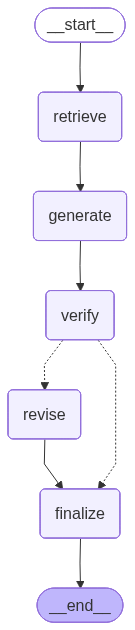

In [9]:
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

HOW MEMORY WORKS (say this in the demo): MemorySaver checkpoints the full state after every turn, keyed by a thread_id. Same thread_id → the agent sees the whole message history. New thread_id → fresh conversation. The add_messages reducer is what accumulates history instead of overwriting it.

In [10]:
import time
from groq import RateLimitError

def ask(question: str, thread_id: str = "demo", max_retries: int = 3) -> str:
    """Send one question to the agent within a persistent conversation thread.

    Groq's free tier caps tokens-per-minute, which the back-to-back demo
    calls below can hit; retry with a short backoff instead of failing the cell.
    """
    config = {"configurable": {"thread_id": thread_id}}
    for attempt in range(max_retries):
        try:
            result = agent.invoke(
                {"messages": [HumanMessage(content=question)]},
                config=config,
            )
            break
        except RateLimitError:
            wait_s = 15
            print(f"  Rate limit hit, retrying in {wait_s}s (attempt {attempt + 1}/{max_retries})...")
            time.sleep(wait_s)
    else:
        raise RuntimeError(f"Failed to get a response after {max_retries} retries")

    answer = result["messages"][-1].content
    verified = result.get("verification", "").upper().startswith("VALID")
    print(f"🧑 Q: {question}\n")
    print(f"🤖 A: {answer}")
    print(f"\n{'✅ Verified as grounded in the context' if verified else '🔁 Revised after failing the groundedness check: ' + result.get('verification', '')}")
    print("\n" + "=" * 70)
    return answer

In [11]:
# Example 1 — Regulation (should cite the EU AI Act)
ask("What is considered a high-risk AI system under the EU AI Act?")

🧑 Q: What is considered a high-risk AI system under the EU AI Act?

🤖 A: According to the EU AI Act, high-risk AI systems are those that pose a significant risk to health, safety, or fundamental rights. These systems are subject to stringent requirements to ensure accuracy, transparency, and compliance with ethical standards.

The Act does not provide an exhaustive list of high-risk AI systems, but it mentions examples, including:

* AI systems used in healthcare, such as medical diagnosis or treatment recommendations
* AI systems used in law enforcement, such as facial recognition or predictive policing
* AI systems used in critical infrastructure, such as power grids or transportation systems

High-risk AI systems are required to undergo rigorous testing, validation, and certification to ensure their safety and reliability. They must also be designed to allow effective human oversight and provide clear explanations of their decision-making processes.

Source: EU AI Act (specifically,

'According to the EU AI Act, high-risk AI systems are those that pose a significant risk to health, safety, or fundamental rights. These systems are subject to stringent requirements to ensure accuracy, transparency, and compliance with ethical standards.\n\nThe Act does not provide an exhaustive list of high-risk AI systems, but it mentions examples, including:\n\n* AI systems used in healthcare, such as medical diagnosis or treatment recommendations\n* AI systems used in law enforcement, such as facial recognition or predictive policing\n* AI systems used in critical infrastructure, such as power grids or transportation systems\n\nHigh-risk AI systems are required to undergo rigorous testing, validation, and certification to ensure their safety and reliability. They must also be designed to allow effective human oversight and provide clear explanations of their decision-making processes.\n\nSource: EU AI Act (specifically, the text describing the risk-based classification system and 

In [12]:
# Example 2 — Technical foundations (should cite the Bias & Fairness survey)
ask("What are the main types of bias that can appear in machine learning systems?")

🧑 Q: What are the main types of bias that can appear in machine learning systems?

🤖 A: According to the "Bias and Fairness in Machine Learning" survey by Mehrabi et al., the main types of bias that can appear in machine learning systems are categorized into three main areas: data, algorithm, and user interaction.

1. **Data Bias**: This occurs when the training data contains biases, which are then learned by the algorithm and reflected in its predictions. Examples include:
	* Measurement Bias: errors in data collection or measurement
	* Sampling Bias: biased sampling of data
	* Selection Bias: biased selection of data
2. **Algorithmic Bias**: This occurs when the algorithm itself introduces biases, even if the data is unbiased. Examples include:
	* Confirmation Bias: algorithms that confirm existing biases
	* Selection Bias: algorithms that select certain data points over others
	* Overfitting: algorithms that fit too closely to the training data
3. **User Interaction Bias**: This occ

'According to the "Bias and Fairness in Machine Learning" survey by Mehrabi et al., the main types of bias that can appear in machine learning systems are categorized into three main areas: data, algorithm, and user interaction.\n\n1. **Data Bias**: This occurs when the training data contains biases, which are then learned by the algorithm and reflected in its predictions. Examples include:\n\t* Measurement Bias: errors in data collection or measurement\n\t* Sampling Bias: biased sampling of data\n\t* Selection Bias: biased selection of data\n2. **Algorithmic Bias**: This occurs when the algorithm itself introduces biases, even if the data is unbiased. Examples include:\n\t* Confirmation Bias: algorithms that confirm existing biases\n\t* Selection Bias: algorithms that select certain data points over others\n\t* Overfitting: algorithms that fit too closely to the training data\n3. **User Interaction Bias**: This occurs when the user\'s interactions with the system introduce biases. Exa

In [13]:
# Example 3 — Ethics principles (should cite the Trustworthy AI Guidelines)
ask("What are the seven key requirements for trustworthy AI in the EU?")

  Rate limit hit, retrying in 15s (attempt 1/3)...


🧑 Q: What are the seven key requirements for trustworthy AI in the EU?

🤖 A: According to the EU's "Ethics Guidelines for Trustworthy AI" and the European Parliament study "The Ethics of Artificial Intelligence: Issues and Initiatives", the seven key requirements for trustworthy AI in the EU are:

1. **Human agency and oversight**: AI systems should be designed to ensure that humans remain in control and can make informed decisions.
2. **Technical robustness and safety**: AI systems should be designed and tested to ensure they are secure, reliable, and function as intended.
3. **Privacy and data governance**: AI systems should be designed to protect personal data and ensure that it is used in accordance with applicable laws and regulations.
4. **Transparency**: AI systems should be designed to provide clear and understandable explanations of their decision-making processes.
5. **Diversity, non-discrimination, and fairness**: AI systems should be designed to avoid perpetuating biases an

'According to the EU\'s "Ethics Guidelines for Trustworthy AI" and the European Parliament study "The Ethics of Artificial Intelligence: Issues and Initiatives", the seven key requirements for trustworthy AI in the EU are:\n\n1. **Human agency and oversight**: AI systems should be designed to ensure that humans remain in control and can make informed decisions.\n2. **Technical robustness and safety**: AI systems should be designed and tested to ensure they are secure, reliable, and function as intended.\n3. **Privacy and data governance**: AI systems should be designed to protect personal data and ensure that it is used in accordance with applicable laws and regulations.\n4. **Transparency**: AI systems should be designed to provide clear and understandable explanations of their decision-making processes.\n5. **Diversity, non-discrimination, and fairness**: AI systems should be designed to avoid perpetuating biases and ensure that they treat all individuals fairly and without discrimin

In [14]:
# Example 4 — Real-world impact (should cite the EP Ethics study)
ask("What ethical concerns does AI raise in healthcare?")

🧑 Q: What ethical concerns does AI raise in healthcare?

🤖 A: According to the European Parliament study "The Ethics of Artificial Intelligence: Issues and Initiatives", AI raises several ethical concerns in healthcare, including:

1. **Training of healthcare professionals**: AI may change the role of healthcare professionals, potentially reducing their autonomy and decision-making power.
2. **Data protection and confidentiality**: AI systems may have access to sensitive patient data, raising concerns about data protection and confidentiality.
3. **Equality and fairness**: AI systems may perpetuate existing biases and inequalities in healthcare, particularly if they are trained on biased data.
4. **Trust and accountability**: Patients may lose trust in healthcare professionals if they rely on AI systems for diagnosis and treatment.
5. **Liability and responsibility**: It may be unclear who is liable if an AI system makes a mistake or causes harm to a patient.
6. **Patient autonomy**: A

'According to the European Parliament study "The Ethics of Artificial Intelligence: Issues and Initiatives", AI raises several ethical concerns in healthcare, including:\n\n1. **Training of healthcare professionals**: AI may change the role of healthcare professionals, potentially reducing their autonomy and decision-making power.\n2. **Data protection and confidentiality**: AI systems may have access to sensitive patient data, raising concerns about data protection and confidentiality.\n3. **Equality and fairness**: AI systems may perpetuate existing biases and inequalities in healthcare, particularly if they are trained on biased data.\n4. **Trust and accountability**: Patients may lose trust in healthcare professionals if they rely on AI systems for diagnosis and treatment.\n5. **Liability and responsibility**: It may be unclear who is liable if an AI system makes a mistake or causes harm to a patient.\n6. **Patient autonomy**: AI systems may limit patient autonomy and decision-maki

In [15]:
# Example 5 — OUT-OF-SCOPE test: the agent should say "I don't know" ⭐
ask("What does Japanese AI regulation say about facial recognition?")

  Rate limit hit, retrying in 15s (attempt 1/3)...


🧑 Q: What does Japanese AI regulation say about facial recognition?

🤖 A: I don't have enough information in my knowledge base to answer that. The context provided does not mention Japan or Japanese AI regulation, so I cannot provide an answer to this question. 

However, you could ask about the regulation of facial recognition in the EU, which is a topic that is relevant to the context provided.

🔁 Revised after failing the groundedness check: INVALID: The draft suggests asking about Japanese AI regulation in general or facial recognition in Japan, but the context does not mention Japan or Japanese AI regulation at all.



"I don't have enough information in my knowledge base to answer that. The context provided does not mention Japan or Japanese AI regulation, so I cannot provide an answer to this question. \n\nHowever, you could ask about the regulation of facial recognition in the EU, which is a topic that is relevant to the context provided."

In [16]:
# Turn 1
ask("What is algorithmic bias?", thread_id="memory-demo")

🧑 Q: What is algorithmic bias?

🤖 A: According to the Bias & Fairness Survey (Mehrabi et al.), algorithmic bias is when the bias is not present in the input data and is added purely by the algorithm. This means that the bias is introduced by the design choices made in the algorithm itself, such as the use of certain optimization functions, regularizations, or statistically biased estimators. As a result, the algorithmic decisions can be biased, leading to unfair outcomes.

Algorithmic bias can occur even if the input data is not biased, highlighting the importance of considering the algorithm's design choices when developing machine learning models.

✅ Verified as grounded in the context



"According to the Bias & Fairness Survey (Mehrabi et al.), algorithmic bias is when the bias is not present in the input data and is added purely by the algorithm. This means that the bias is introduced by the design choices made in the algorithm itself, such as the use of certain optimization functions, regularizations, or statistically biased estimators. As a result, the algorithmic decisions can be biased, leading to unfair outcomes.\n\nAlgorithmic bias can occur even if the input data is not biased, highlighting the importance of considering the algorithm's design choices when developing machine learning models."

In [17]:
# Turn 2 — refers to "it" with no other clue: only works if memory works
ask("Can you give me two real-world examples of it?", thread_id="memory-demo")

🧑 Q: Can you give me two real-world examples of it?

🤖 A: I don't have enough information in my knowledge base to answer that. However, I can suggest asking about specific examples of algorithmic bias in the context of the European AI ethics and regulation, such as the potential for bias in AI systems used for decision-making in areas like law enforcement or finance.

🔁 Revised after failing the groundedness check: INVALID: The draft answer references the Bias & Fairness Survey (Mehrabi et al.) but the provided context does not mention this source, nor does it mention Google's Image Recognition Bias or the COMPAS Risk Assessment Tool, which are the two examples provided in the draft answer.



"I don't have enough information in my knowledge base to answer that. However, I can suggest asking about specific examples of algorithmic bias in the context of the European AI ethics and regulation, such as the potential for bias in AI systems used for decision-making in areas like law enforcement or finance."

In [18]:
# Turn 3 — refers to the whole previous exchange
ask("Which of those two examples is covered by the EU AI Act?", thread_id="memory-demo")

🧑 Q: Which of those two examples is covered by the EU AI Act?

🤖 A: Based on the provided context, I don't have enough information to determine which of the two examples (law enforcement or finance) is covered by the EU AI Act. The context mentions that the Act sets a benchmark for AI governance and integration that aligns with ethics, democratic values, safeguards individual rights, and fosters public trust, but it does not specifically mention law enforcement or finance.

However, it does mention that the Act categorizes AI systems into different risk levels based on their potential impact on safety and fundamental rights, and that systems deemed "unacceptable," such as those infringing on privacy or perpetuating discrimination, are outright banned. This suggests that the Act may cover areas related to privacy and discrimination, but it does not provide enough information to determine whether law enforcement or finance are explicitly covered.

🔁 Revised after failing the groundedness

'Based on the provided context, I don\'t have enough information to determine which of the two examples (law enforcement or finance) is covered by the EU AI Act. The context mentions that the Act sets a benchmark for AI governance and integration that aligns with ethics, democratic values, safeguards individual rights, and fosters public trust, but it does not specifically mention law enforcement or finance.\n\nHowever, it does mention that the Act categorizes AI systems into different risk levels based on their potential impact on safety and fundamental rights, and that systems deemed "unacceptable," such as those infringing on privacy or perpetuating discrimination, are outright banned. This suggests that the Act may cover areas related to privacy and discrimination, but it does not provide enough information to determine whether law enforcement or finance are explicitly covered.'

In [19]:
print("💬 AI Ethics Assistant — type your question ('exit' to quit)\n")

while True:
    try:
        question = input("You: ").strip()
    except Exception:
        # No interactive stdin available (e.g. batch/CI execution, or a
        # headless kernel that raises StdinNotImplementedError instead of
        # EOFError) — stop cleanly rather than crashing the cell.
        print("(no interactive input available — skipping chat loop)")
        break
    if question.lower() in {"exit", "quit", "salir"}:
        print("Goodbye! 👋")
        break
    if question:
        ask(question, thread_id="interactive")

💬 AI Ethics Assistant — type your question ('exit' to quit)

(no interactive input available — skipping chat loop)
